# Pneumonia Classification — Classical ML with Patient-Level CV and PCA

This notebook uses handcrafted image features followed by **patient-level train/test splitting**. Logistic Regression, Random Forest, and SVM are tuned using **GroupKFold cross-validation**. Standardization and PCA are placed inside model pipelines so preprocessing is fitted separately within each CV fold, preventing cross-validation leakage.

**PCA is used for dimensionality reduction / feature selection at the component level.** The number of retained components is selected using explained-variance thresholds (90%, 95%, 99%) during cross-validation.

The final test set is kept completely outside hyperparameter tuning and is used only for final evaluation.


In [8]:
#!pip install -q scikit-image pywavelets --upgrade

In [9]:
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from skimage.feature import graycomatrix, graycoprops, hog

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    GroupShuffleSplit,
    GroupKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

import re


In [10]:
import os

def find_train_test_dirs(root="/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia"):
    train_dir, test_dir = None, None
    for dirpath, dirnames, _ in os.walk(root):
        if "NORMAL" in dirnames and "PNEUMONIA" in dirnames:
            base_name = os.path.basename(dirpath).lower()
            if "train" in base_name:
                train_dir = dirpath
            elif "test" in base_name:
                test_dir = dirpath
    return train_dir, test_dir

TRAIN_DIR, TEST_DIR = find_train_test_dirs()
assert TRAIN_DIR is not None and TEST_DIR is not None, "Train or Test directory not found!"

print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)

Train dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Test dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test


In [11]:
import os
import re
import pandas as pd

# Define the random seed for reproducibility
SEED = 42

def build_dataframe(root_dir, split_name):
    records = []
    label_map = {"NORMAL": 0, "PNEUMONIA": 1}
    valid_ext = (".jpeg", ".jpg", ".png", ".bmp")
    for label_name, class_id in label_map.items():
        class_folder = os.path.join(root_dir, label_name)
        if not os.path.isdir(class_folder):
            continue
        for fname in os.listdir(class_folder):
            if fname.lower().endswith(valid_ext):
                fpath = os.path.join(class_folder, fname)
                records.append({
                    "image_path": fpath, 
                    "label": label_name, 
                    "class_id": class_id, 
                    "split": split_name
                })
    return pd.DataFrame(records)

train_df_raw = build_dataframe(TRAIN_DIR, "train")
test_df_raw = build_dataframe(TEST_DIR, "test")
universal_df = pd.concat([train_df_raw, test_df_raw], ignore_index=True)
universal_df = universal_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

def extract_patient_id(image_path):
    fname = os.path.basename(image_path)
    m = re.match(r"person(\d+)_", fname)
    if m:
        return f"pneumonia_{m.group(1)}"
    m = re.search(r"IM-(\d+)-", fname)
    if m:
        return f"normal_{m.group(1)}"
    return fname

universal_df["patient_id"] = universal_df["image_path"].apply(extract_patient_id)
print("Unique patients found:", universal_df["patient_id"].nunique(), "across", len(universal_df), "images")

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
NUM_CLASSES = 2
print("Total images found:", len(universal_df))
universal_df.head()

Unique patients found: 2775 across 5840 images
Total images found: 5840


,image_path,label,class_id,split,patient_id
0,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train,pneumonia_291
1,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,0,train,normal_0575
2,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,0,train,normal_0458
3,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train,pneumonia_1124
4,/kaggle/input/datasets/paultimothymooney/chest...,PNEUMONIA,1,train,pneumonia_342


In [12]:
def is_valid_image(path):
    img = cv2.imread(path)
    return img is not None

with ThreadPoolExecutor(max_workers=16) as executor:
    validity_results = list(executor.map(is_valid_image, universal_df["image_path"]))
universal_df["is_valid"] = validity_results
print("Corrupt/unreadable images:", (~universal_df["is_valid"]).sum())
universal_df = universal_df[universal_df["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)
print("Final clean dataset size:", len(universal_df))

Corrupt/unreadable images: 0
Final clean dataset size: 5840


/tmp/ipykernel_58/3351664451.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="viridis")


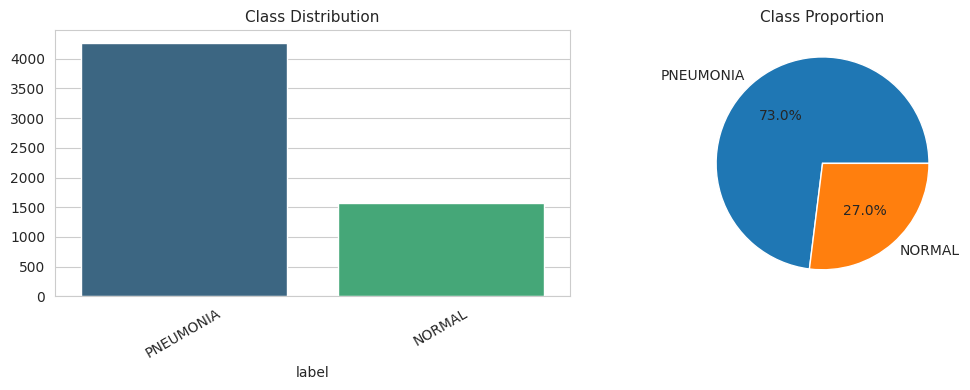

Class Imbalance Ratio: 2.71 : 1


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
class_counts = universal_df["label"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Class Distribution", fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%")
axes[1].set_title("Class Proportion", fontsize=11)
plt.tight_layout(); plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f} : 1")

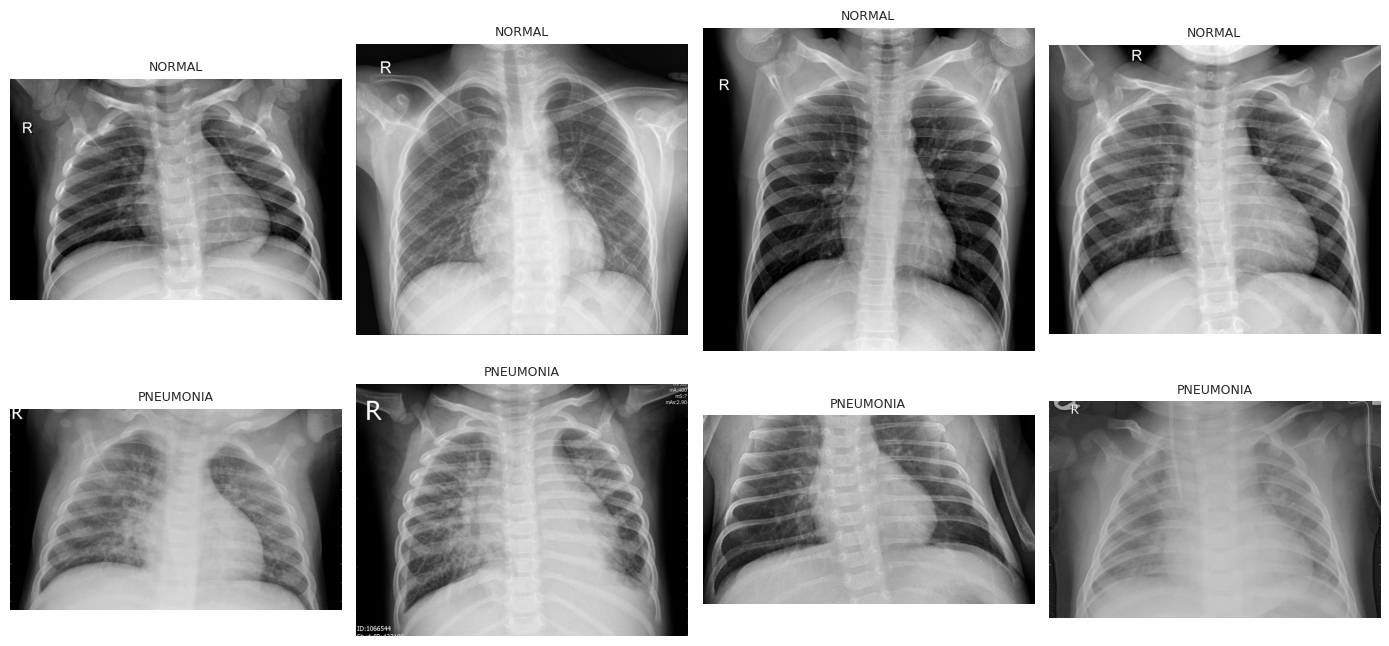

In [14]:
normal_samples = universal_df[universal_df["label"] == "NORMAL"].sample(4, random_state=SEED)
pneumonia_samples = universal_df[universal_df["label"] == "PNEUMONIA"].sample(4, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img); axes[0, i].set_title("NORMAL", fontsize=9); axes[0, i].axis("off")
for i, (_, row) in enumerate(pneumonia_samples.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img); axes[1, i].set_title("PNEUMONIA", fontsize=9); axes[1, i].axis("off")
plt.tight_layout(); plt.show()

In [15]:
IMG_SIZE = (32, 32)
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    resized = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return resized
def extract_basic_features(img):
    hist, _ = np.histogram(img, bins=8, range=(0, 256), density=True)
    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    glcm_feats = np.array([graycoprops(glcm, p)[0, 0] for p in ["contrast", "homogeneity", "energy", "correlation"]])
    stats = np.array([img.mean(), img.std()])
    return np.concatenate([hist, glcm_feats, stats])
def extract_all_features(image_path):
    img = preprocess_image(image_path)
    return extract_basic_features(img)

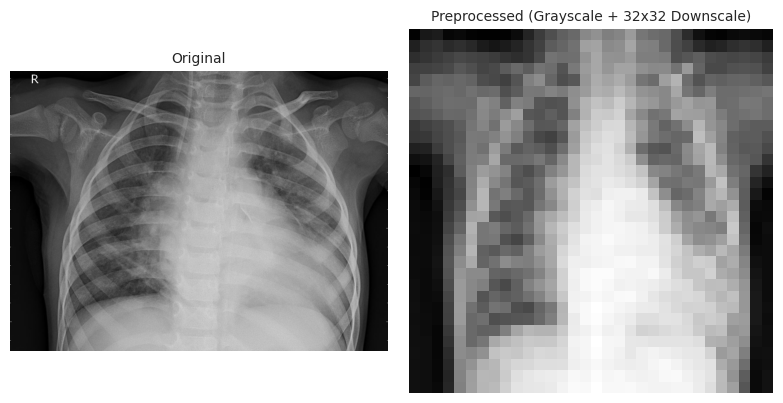

Feature vector length per image: 14


In [16]:
sample_path = universal_df.iloc[0]["image_path"]
original = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
processed = preprocess_image(sample_path)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original); axes[0].set_title("Original", fontsize=10); axes[0].axis("off")
axes[1].imshow(processed, cmap="gray"); axes[1].set_title("Preprocessed (Grayscale + 32x32 Downscale)", fontsize=10); axes[1].axis("off")
plt.tight_layout(); plt.show()
sample_feats = extract_all_features(sample_path)
print("Feature vector length per image:", len(sample_feats))

In [17]:
with ThreadPoolExecutor(max_workers=8) as executor:
    feature_list = list(executor.map(extract_all_features, universal_df["image_path"]))

X_all = np.array(feature_list)
y_all = universal_df["class_id"].values
print("Feature matrix shape:", X_all.shape)

Feature matrix shape: (5840, 14)


In [18]:
# ============================================================
# Patient-level train/test split
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, test_idx = next(
    gss.split(
        X_all,
        y_all,
        groups=universal_df["patient_id"]
    )
)

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

train_patients = set(universal_df.loc[train_idx, "patient_id"])
test_patients = set(universal_df.loc[test_idx, "patient_id"])

overlap = train_patients & test_patients

print(
    f"Train: {X_train.shape[0]} samples "
    f"({X_train.shape[0]/len(X_all):.1%}) | "
    f"Unique patients: {len(train_patients)}"
)
print(
    f"Test:  {X_test.shape[0]} samples "
    f"({X_test.shape[0]/len(X_all):.1%}) | "
    f"Unique patients: {len(test_patients)}"
)

print("\nClass balance check (train):", np.bincount(y_train))
print("Class balance check (test):", np.bincount(y_test))

print(
    f"\nPatient overlap between train and test: "
    f"{len(overlap)} (should be 0)"
)

assert len(overlap) == 0, "Patient leakage detected!"

# Patient IDs for the training samples.
# These are passed to GroupKFold so that the same patient
# cannot appear in both the training and validation fold.
train_groups = universal_df.loc[train_idx, "patient_id"].values

group_cv = GroupKFold(n_splits=5)

print("\nUsing GroupKFold with 5 folds.")
print("Unique training patients:", len(np.unique(train_groups)))


Train: 4681 samples (80.2%) | Unique patients: 2220
Test:  1159 samples (19.8%) | Unique patients: 555

Class balance check (train): [1237 3444]
Class balance check (test): [338 821]

Patient overlap between train and test: 0 (should be 0)

Using GroupKFold with 5 folds.
Unique training patients: 2220


In [19]:
# ============================================================
# PCA setup
# ============================================================
# PCA is treated as dimensionality reduction / feature selection.
#
# IMPORTANT:
# StandardScaler and PCA are NOT fitted here.
# They are placed inside each model Pipeline so that, during
# cross-validation, both are fitted only on the training portion
# of each CV fold. This prevents CV preprocessing leakage.
#
# We will tune the amount of retained variance:
#   90%, 95%, and 99%.
# ============================================================

print("Original feature dimensions:", X_train.shape[1])
print("PCA will be fitted inside each CV fold.")


Original feature dimensions: 14
PCA will be fitted inside each CV fold.


In [20]:
# ============================================================
# Logistic Regression + Scaling + PCA + GroupKFold
# ============================================================

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=SEED)),
    ("model", LogisticRegression(
        random_state=SEED,
        max_iter=1000
    ))
])

lr_param_grid = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=group_cv,
    scoring="f1_macro",
    n_jobs=-1
)

lr_grid.fit(
    X_train,
    y_train,
    groups=train_groups
)

lr_model = lr_grid.best_estimator_

print("Best Logistic Regression params:")
print(lr_grid.best_params_)
print("Best CV F1-macro:", round(lr_grid.best_score_, 4))
print(
    "Selected PCA components:",
    lr_model.named_steps["pca"].n_components_
)
print(
    "Explained variance retained:",
    round(
        lr_model.named_steps["pca"].explained_variance_ratio_.sum(),
        4
    )
)


Best Logistic Regression params:
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'pca__n_components': 0.99}
Best CV F1-macro: 0.7314
Selected PCA components: 11
Explained variance retained: 0.9985


In [21]:
# ============================================================
# Random Forest + Scaling + PCA + GroupKFold
# ============================================================
# The previous RF showed a large train/test gap. Therefore,
# the search space below restricts tree complexity and adds
# stronger regularization.
#
# PCA is included because it was requested for feature reduction.
# The final model is selected using patient-aware CV, not the test set.
# ============================================================

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=SEED)),
    ("model", RandomForestClassifier(
        random_state=SEED,
        n_jobs=-1
    ))
])

rf_param_dist = {
    "pca__n_components": [0.90, 0.95, 0.99],

    "model__n_estimators": [200, 300, 500],

    # More constrained than the previous search to reduce overfitting
    "model__max_depth": [6, 8, 10, 12, 15],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf": [2, 4, 8],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

rf_random = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=group_cv,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=SEED
)

rf_random.fit(
    X_train,
    y_train,
    groups=train_groups
)

rf_model = rf_random.best_estimator_

print("Best Random Forest params:")
print(rf_random.best_params_)
print("Best CV F1-macro:", round(rf_random.best_score_, 4))
print(
    "Selected PCA components:",
    rf_model.named_steps["pca"].n_components_
)
print(
    "Explained variance retained:",
    round(
        rf_model.named_steps["pca"].explained_variance_ratio_.sum(),
        4
    )
)


Best Random Forest params:
{'pca__n_components': 0.99, 'model__n_estimators': 300, 'model__min_samples_split': 20, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 15, 'model__class_weight': 'balanced'}
Best CV F1-macro: 0.811
Selected PCA components: 11
Explained variance retained: 0.9985


In [22]:
# ============================================================
# SVM + Scaling + PCA + GroupKFold
# ============================================================

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=SEED)),
    ("model", SVC(
        probability=True,
        random_state=SEED
    ))
])

svm_param_grid = [
    {
        "pca__n_components": [0.90, 0.95, 0.99],
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10]
    },
    {
        "pca__n_components": [0.90, 0.95, 0.99],
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
]

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=group_cv,
    scoring="f1_macro",
    n_jobs=-1
)

svm_grid.fit(
    X_train,
    y_train,
    groups=train_groups
)

svm_model = svm_grid.best_estimator_

print("Best SVM params:")
print(svm_grid.best_params_)
print("Best CV F1-macro:", round(svm_grid.best_score_, 4))
print(
    "Selected PCA components:",
    svm_model.named_steps["pca"].n_components_
)
print(
    "Explained variance retained:",
    round(
        svm_model.named_steps["pca"].explained_variance_ratio_.sum(),
        4
    )
)


Best SVM params:
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf', 'pca__n_components': 0.99}
Best CV F1-macro: 0.8423
Selected PCA components: 11
Explained variance retained: 0.9985


In [23]:
# ============================================================
# Final evaluation on the untouched patient-level test set
# ============================================================

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
    }

models_dict = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

results = {}

for name, model in models_dict.items():

    # The pipeline applies scaling + PCA automatically.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_metrics = compute_metrics(y_train, y_train_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    y_test_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_test_proba)

    results[name] = {
        "train": train_metrics,
        "test": test_metrics,
        "auc": test_auc,
        "y_test_pred": y_test_pred,
        "y_test_proba": y_test_proba
    }

    print(f"\n===== {name} =====")
    print("Train:", train_metrics)
    print(
        "Test :",
        test_metrics,
        "| AUC:",
        round(test_auc, 4)
    )



===== Logistic Regression =====
Train: {'Accuracy': 0.8038880581072421, 'Precision': 0.8443293347873501, 'Recall': 0.8992450638792102, 'F1-Score': 0.8709223847019123}
Test : {'Accuracy': 0.8067299396031061, 'Precision': 0.8342665173572228, 'Recall': 0.9074299634591961, 'F1-Score': 0.8693115519253208} | AUC: 0.8849

===== Random Forest =====
Train: {'Accuracy': 0.924802392651143, 'Precision': 0.9748157248157249, 'Recall': 0.921602787456446, 'F1-Score': 0.9474626865671641}
Test : {'Accuracy': 0.8654012079378774, 'Precision': 0.9161451814768461, 'Recall': 0.8915956151035322, 'F1-Score': 0.9037037037037037} | AUC: 0.9237

===== SVM =====
Train: {'Accuracy': 0.9126255073702201, 'Precision': 0.9392185238784371, 'Recall': 0.9422183507549361, 'F1-Score': 0.9407160458037397}
Test : {'Accuracy': 0.8679896462467644, 'Precision': 0.8957345971563981, 'Recall': 0.9208282582216809, 'F1-Score': 0.9081081081081082} | AUC: 0.9238


In [24]:
# ============================================================
# PCA summary for the selected models
# ============================================================

pca_summary = []

for name, model in models_dict.items():
    pca = model.named_steps["pca"]
    pca_summary.append({
        "Model": name,
        "Original Features": X_train.shape[1],
        "Selected PCA Components": pca.n_components_,
        "Explained Variance": round(
            pca.explained_variance_ratio_.sum(), 4
        )
    })

pca_summary_df = pd.DataFrame(pca_summary)
pca_summary_df


,Model,Original Features,Selected PCA Components,Explained Variance
0,Logistic Regression,14,11,0.9985
1,Random Forest,14,11,0.9985
2,SVM,14,11,0.9985


In [25]:
for name, res in results.items():
    print(f"\n===== Classification Report: {name} (Test Set) =====")
    print(classification_report(y_test, res["y_test_pred"], target_names=CLASS_NAMES))


===== Classification Report: Logistic Regression (Test Set) =====
              precision    recall  f1-score   support

      NORMAL       0.71      0.56      0.63       338
   PNEUMONIA       0.83      0.91      0.87       821

    accuracy                           0.81      1159
   macro avg       0.77      0.73      0.75      1159
weighted avg       0.80      0.81      0.80      1159


===== Classification Report: Random Forest (Test Set) =====
              precision    recall  f1-score   support

      NORMAL       0.75      0.80      0.78       338
   PNEUMONIA       0.92      0.89      0.90       821

    accuracy                           0.87      1159
   macro avg       0.83      0.85      0.84      1159
weighted avg       0.87      0.87      0.87      1159


===== Classification Report: SVM (Test Set) =====
              precision    recall  f1-score   support

      NORMAL       0.79      0.74      0.77       338
   PNEUMONIA       0.90      0.92      0.91       821

   

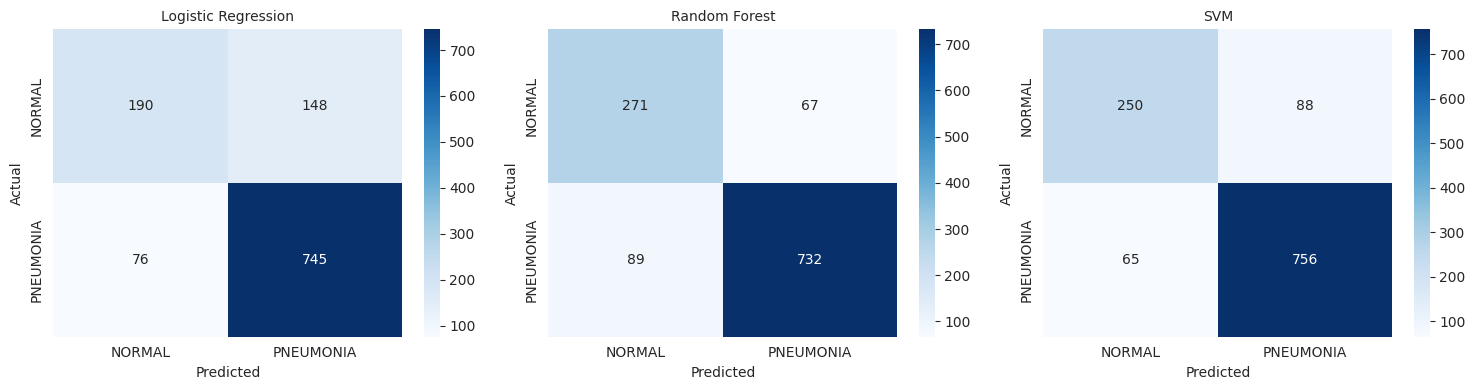

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i], xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")
plt.tight_layout(); plt.show()

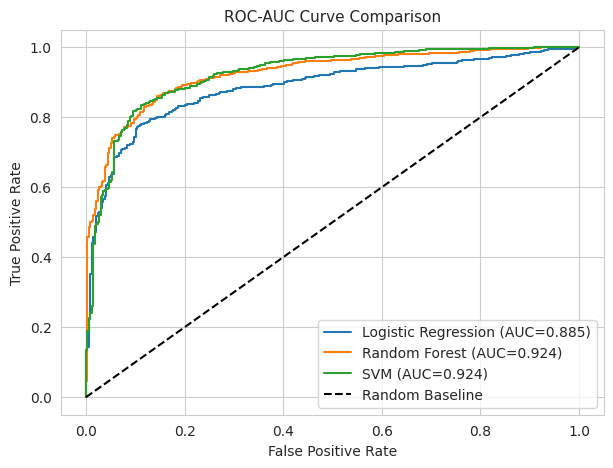

In [27]:
plt.figure(figsize=(7, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_test_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison", fontsize=11); plt.legend()
plt.show()

In [28]:
comparison_rows = []
for name, res in results.items():
    row = {"Model": name, **{f"Test {k}": round(v, 4) for k, v in res["test"].items()}, "AUC": round(res["auc"], 4)}
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
best_model_name = comparison_df.iloc[0]["Model"]
print(f" Best performing model: {best_model_name}")
comparison_df

 Best performing model: SVM


,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score,AUC
0,SVM,0.8680,0.8957,0.9208,0.9081,0.9238
1,Random Forest,0.8654,0.9161,0.8916,0.9037,0.9237
2,Logistic Regression,0.8067,0.8343,0.9074,0.8693,0.8849
